1. Install and configure TensorFlow/Keras in Google Colab. Perform data preprocessing,
normalization, train-test splitting, and data visualization on a sample dataset.

In [ ]:
import tensorflow as tf

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow import keras

In [ ]:
iris = load_iris()

x = iris.data
y = iris.target

print(x[:5])
print(y[:5])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0]


In [ ]:
df = pd.DataFrame(x, columns=iris.feature_names)
df['Special'] = y

print(df.head())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Special  
0        0  
1        0  
2        0  
3        0  
4        0  


In [ ]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Special            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Special
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


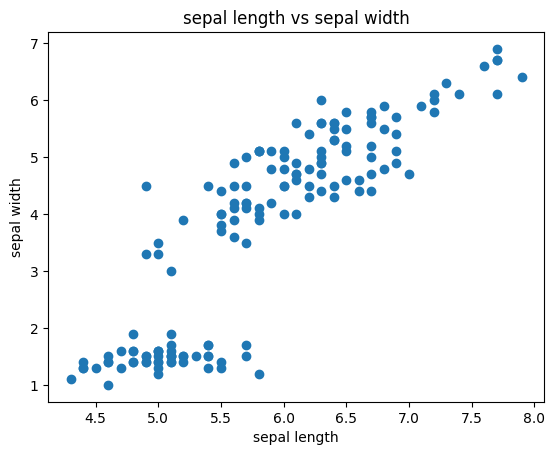

In [ ]:
plt.scatter(x[:,0],x[:,2])
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.title('sepal length vs sepal width')
plt.show()

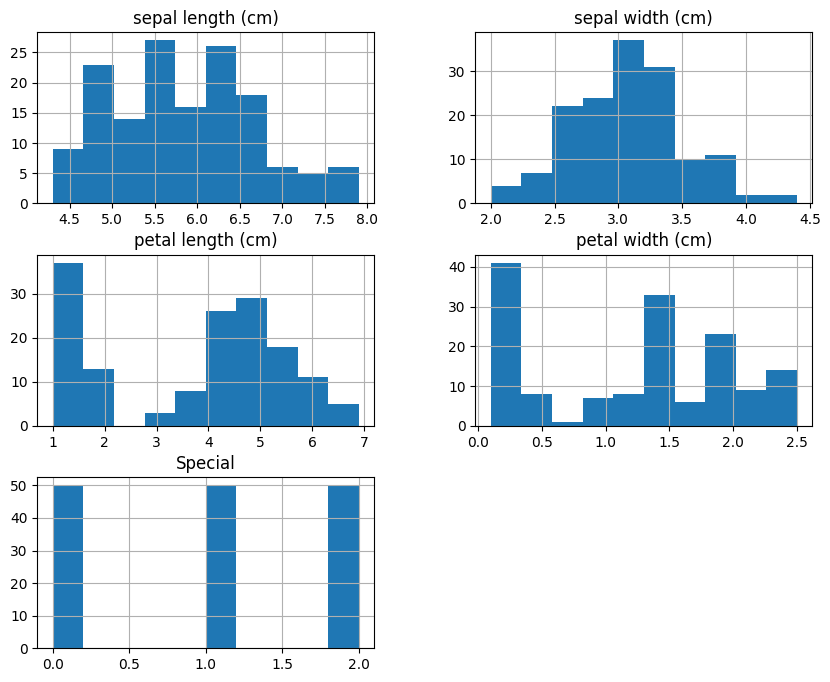

In [ ]:
df.hist(figsize=(10, 8))
plt.show()

In [ ]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
print(x_scaled[:5])

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42, stratify = y)

print("Traning Data :", X_train.shape)
print("Testing Data :",X_test.shape)

print("Traning Label :", y_train.shape)
print("Testing Label :",y_test.shape)

Traning Data : (120, 4)
Testing Data : (30, 4)
Traning Label : (120,)
Testing Label : (30,)


In [ ]:
model = keras.Sequential([
    keras.layers.Dense(16, input_shape=(4,), activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_test, y_test))

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.3333 - loss: 1.1552 - val_accuracy: 0.3333 - val_loss: 1.0720
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3333 - loss: 1.1548 - val_accuracy: 0.3333 - val_loss: 1.0559
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3333 - loss: 1.0970 - val_accuracy: 0.3333 - val_loss: 1.0422
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3333 - loss: 1.1159 - val_accuracy: 0.3333 - val_loss: 1.0297
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3333 - loss: 1.0615 - val_accuracy: 0.3333 - val_loss: 1.0178
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3333 - loss: 1.0452 - val_accuracy: 0.3333 - val_loss: 1.0062
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3333 - loss: 1.0416 - val_accuracy: 0.3000 - val_loss: 0.9945
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3500 - loss: 1.0145 - val_accuracy: 0.3000 - val_loss: 0.9830


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print('Test Loss:',loss)
print('Test Accuracy: ',accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7333 - loss: 0.7585
Test Loss: 0.7585248947143555
Test Accuracy:  0.7333333492279053


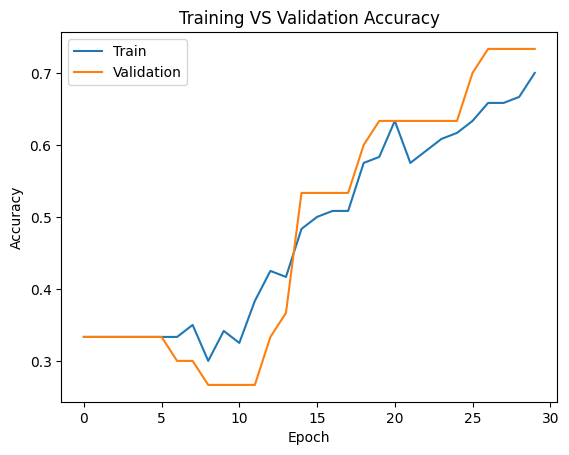

In [ ]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training VS Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

In [ ]:
predictions = model.predict(X_test)
print(predictions[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
[[0.35339594 0.40080875 0.24579535]
 [0.09828965 0.3297617  0.57194865]
 [0.12483259 0.7097791  0.16538835]
 [0.09815396 0.7523361  0.1495099 ]
 [0.3558467  0.3903567  0.2537967 ]]


In [ ]:
predicted_classes = np.argmax(predictions, axis=1)

print("Predicted",predicted_classes[:10])
print("Actual :", y_test[:10])

Predicted [1 2 1 1 1 2 0 0 2 1]
Actual : [0 2 1 1 0 1 0 0 2 1]
